## Задание 1

Для начала  сформулируем гипотезы для проверки.

* **Нулевая гипотеза (H0): Разницы между средним временем доставки в тестовой и контрольной группе нет**

* **Альтернативная гипотеза (H1): Разница между средним временем доставки в тестовой и контрольной группе есть**


# Задание 2
Сопоставьте графики распределения и  экспериментальные группы:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import scipy
from scipy import stats

In [2]:
data = pd.read_csv('C:/Users/majkl/WorkSpace/Project_st_4/experiment_lesson_4.csv')
data.head()

,order_id,delivery_time,district,experiment_group
0,3159,44.0,Purlieus,control
1,10426,51.0,Purlieus,control
2,9155,46.0,Purlieus,control
3,10699,34.0,Purlieus,control
4,10061,43.0,Purlieus,control


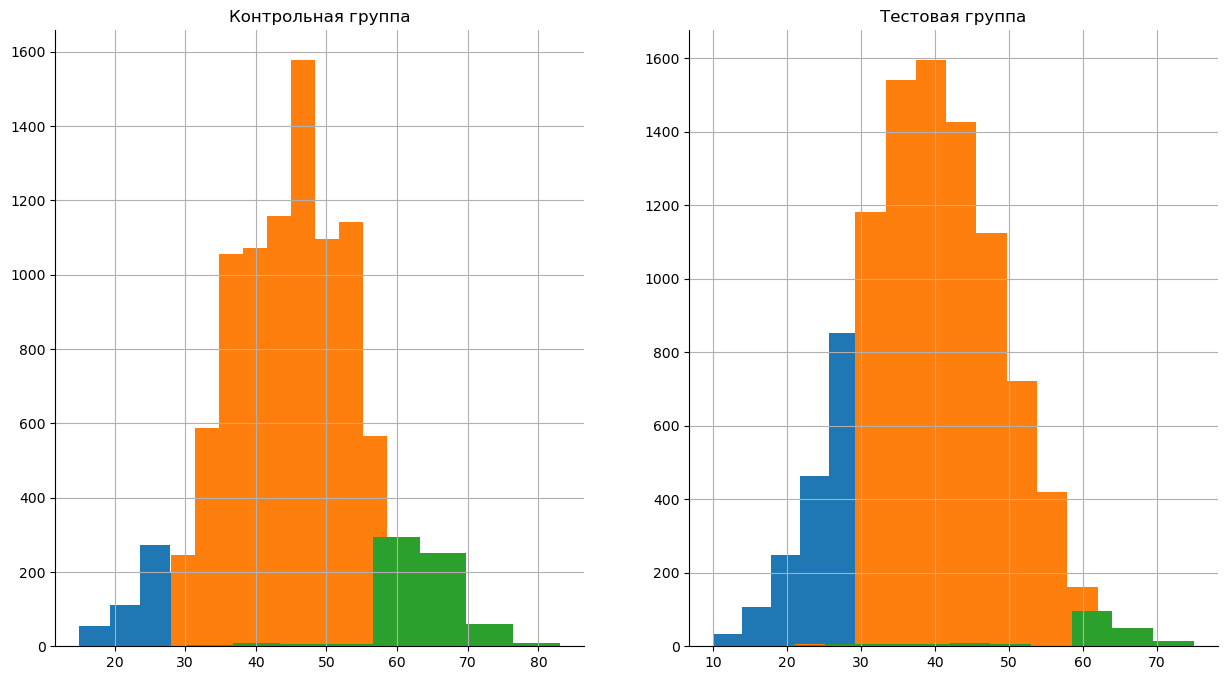

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
data.query("experiment_group == 'control'").groupby('district').delivery_time.hist(ax=axes[0])
axes[0].set_title('Контрольная группа')
data.query("experiment_group == 'test'").groupby('district').delivery_time.hist(ax=axes[1])
axes[1].set_title('Тестовая группа')

sns.despine()

# Задание 3
Посчитайте количество наблюдений в тестовой и контрольной группе. На сколько по модулю отличается количество наблюдений в тесте и контроле?

In [17]:
min = data.query("experiment_group == 'test'").value_counts().sum() - data.query("experiment_group == 'control'").value_counts().sum()
print(f'Разница составляет: {min}')

Разница составляет: 12


# Задание 4
Изучим наши распределения. Проверим выполнение условий на нормальность и посчитаем стандартное отклонение в тесте и в контроле.

In [18]:
scipy.stats.shapiro(data[data['experiment_group'] == 'test']['delivery_time'].sample(1000, random_state=17))

ShapiroResult(statistic=0.9975429485383064, pvalue=0.13902241238486684)

In [19]:
scipy.stats.shapiro(data[data['experiment_group'] == 'control']['delivery_time'].sample(1000, random_state=17))

ShapiroResult(statistic=0.9974716381542054, pvalue=0.12392829880543466)

In [20]:
np.round(data.query("experiment_group == 'test'").delivery_time.std(), 2)

9.88

In [21]:
np.round(data.query("experiment_group == 'control'").delivery_time.std(), 2)

9.99

Для того, чтобы проверить нормальность распределения, используем `SHAPIRO-WILK TEST`. Этот тест показывает, что значения в тестовой группе распределены `НОРМАЛЬНО`. В контрольной группе распределение является `НОРМАЛЬНЫМ`. Стандартное отклонение времени доставки в тесте равно  `9.88`. Стандартное отклонение времени доставки в контроле равно  `9.99`.




# Задание 5

Сравнить средние в тесте и контроле.

In [22]:
scipy.stats.ttest_ind(data.query("experiment_group == 'test'").delivery_time, 
                      data.query("experiment_group == 'control'").delivery_time )

TtestResult(statistic=-43.03582663183714, pvalue=0.0, df=20194.0)

Для сравнения средних в данных экспериментальных группах  используем `STUDENT'S T-TEST`. Статистика в тесте равна  `-43`, p-value `<= 0.05`.


# Задание 6

На сколько процентов изменилось среднее время доставки в тестовой группе по сравнению с контрольной? 


In [23]:
data.query("experiment_group == 'test'").delivery_time.mean()

39.04681314330958

In [24]:
data.query("experiment_group == 'control'").delivery_time.mean()

45.065101070154576

In [26]:
val = np.round(((data.query("experiment_group == 'test'").delivery_time.mean() -
         data.query("experiment_group == 'control'").delivery_time.mean()) / 
         data.query("experiment_group == 'control'").delivery_time.mean()) * 100, 2)

In [27]:
print(f'Средние время доставки изменилось на {val}')

Средние время доставки изменилось на -13.35


Согласно данным исследования можно применять новый алгоритм на всех, так как среднее время доставки статистически значимо изменилось. Среднее время доставки в тесте меньше, чем в контроле.